In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
from sklearn.covariance import LedoitWolf
from mcmc_core import run_hybrid_adaptive_mcmc

In [22]:
# ---------------------------------------------------------
# 1. Load data and calculate raw summary statistics per replicate
# ---------------------------------------------------------
obs_infected = pd.read_csv('data/infected_timeseries.csv')
obs_rewiring = pd.read_csv('data/rewiring_timeseries.csv')
obs_degrees = pd.read_csv('data/final_degree_histograms.csv')

# Calculate Peak Infected Fraction per replicate
peaks_per_rep = obs_infected.groupby('replicate_id')['infected_fraction'].max().values

# Calculate Total Rewiring Counts per replicate
rewires_per_rep = obs_rewiring.groupby('replicate_id')['rewire_count'].sum().values

# Calculate Degree Variance per replicate (N=200)
obs_degrees['deg_x_count'] = obs_degrees['degree'] * obs_degrees['count']
obs_degrees['deg2_x_count'] = (obs_degrees['degree']**2) * obs_degrees['count']
mean_deg_per_rep = obs_degrees.groupby('replicate_id')['deg_x_count'].sum() / 200
var_deg_per_rep = (obs_degrees.groupby('replicate_id')['deg2_x_count'].sum() / 200) - mean_deg_per_rep**2
var_deg_per_rep = var_deg_per_rep.values

# Calculate Weighted Mean Time (Center of Mass) instead of discrete argmax
# This provides a continuous metric for better normality
def get_weighted_time(group):
    times = group['time'].values
    fractions = group['infected_fraction'].values
    if np.sum(fractions) == 0: return 0
    return np.sum(times * fractions) / np.sum(fractions)

weighted_time_per_rep = obs_infected.groupby('replicate_id').apply(get_weighted_time).values

# Consolidate into a 40x4 matrix (one row per independent replicate)
X_raw = np.column_stack([peaks_per_rep, rewires_per_rep, var_deg_per_rep, weighted_time_per_rep])

# ---------------------------------------------------------
# 2. Empirical Target Specification via Bootstrapping (Thesis Method)
# ---------------------------------------------------------
n_boot = 10000
n_samples = X_raw.shape[0] # R=40
boot_means = np.zeros((n_boot, 4))

np.random.seed(100)
for i in range(n_boot):
    # Sample replicates with replacement (Row-wise bootstrap)
    resample_idx = np.random.choice(n_samples, size=n_samples, replace=True)
    resample_data = X_raw[resample_idx]
    # Calculate the mean vector for this bootstrap sample
    boot_means[i] = np.mean(resample_data, axis=0)

# The bootstrapped mean represents a robust target for the center of the distribution
target_mu_raw = np.mean(boot_means, axis=0)

# ---------------------------------------------------------
# 3. Log-transform and finalize target mu and stable covariance
# ---------------------------------------------------------
# Indices: 0=peak, 1=rewires, 2=var_deg, 3=weighted_time
# Apply Log to rewires, var_deg, and time to equalize scale and improve normality
target_mu = np.array([
    target_mu_raw[0],             # Peak (keep linear)
    np.log(target_mu_raw[1]),     # Log Total Rewires
    np.log(target_mu_raw[2]),     # Log Degree Variance
    np.log(target_mu_raw[3])      # Log Weighted Mean Time
])

# Log-transform the raw data to calculate a stable covariance matrix
X_log = np.copy(X_raw)
X_log[:, 1] = np.log(X_log[:, 1])
X_log[:, 2] = np.log(X_log[:, 2])
X_log[:, 3] = np.log(X_log[:, 3])

# Use Ledoit-Wolf for a robust and non-singular covariance matrix
lw = LedoitWolf()
lw.fit(X_log)
target_cov = lw.covariance_

print("--- Target Specification Complete ---")
print("Target Mu (Log-space):", target_mu)
print("Stable Target Covariance Matrix (Log-space):\n", target_cov)

--- Target Specification Complete ---
Target Mu (Log-space): [0.65721578 6.3010943  2.33585544 2.84835984]
Stable Target Covariance Matrix (Log-space):
 [[ 0.0029442  -0.00110107 -0.00056352 -0.00028837]
 [-0.00110107  0.00557631  0.0020044   0.00301702]
 [-0.00056352  0.0020044   0.01250263  0.00165422]
 [-0.00028837  0.00301702  0.00165422  0.00827723]]


Saved finalized normality check plots to: plots/target_normality_check_mcmc_2.pdf


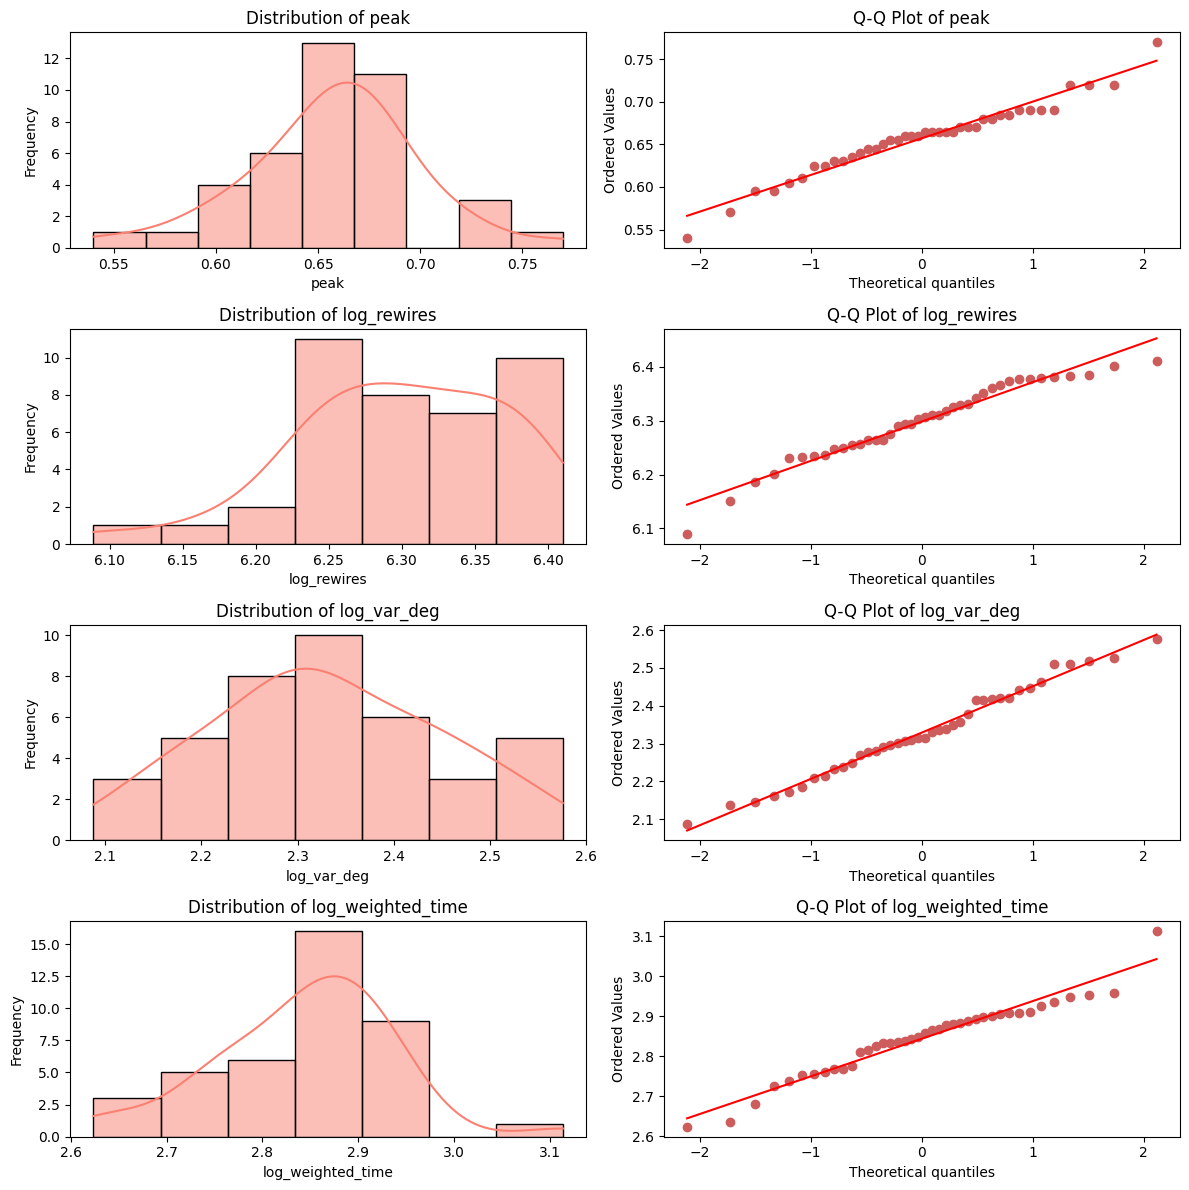

In [23]:
# ---------------------------------------------------------
# Check Normality of Summary Statistics (Histograms & Q-Q Plots)
# ---------------------------------------------------------

# Updated names to reflect the transformations
# X_log columns: 0=peak, 1=log_rewires, 2=log_var_deg, 3=log_weighted_time
stats_labels = ['peak', 'log_rewires', 'log_var_deg', 'log_weighted_time']
n_stats = len(stats_labels)

fig, axes = plt.subplots(n_stats, 2, figsize=(12, 3 * n_stats))

for i, label in enumerate(stats_labels):
    # Extract data from the same X_log used for Ledoit-Wolf
    data = X_log[:, i]
    
    # 1. Histogram with KDE (Left column)
    sns.histplot(data, kde=True, ax=axes[i, 0], color='salmon', edgecolor='black')
    axes[i, 0].set_title(f'Distribution of {label}')
    axes[i, 0].set_xlabel(label)
    axes[i, 0].set_ylabel('Frequency')
    
    # 2. Q-Q Plot (Right column)
    stats.probplot(data, dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f'Q-Q Plot of {label}')
    # Styling to match the thesis aesthetics
    axes[i, 1].get_lines()[0].set_markerfacecolor('indianred')
    axes[i, 1].get_lines()[0].set_markeredgecolor('indianred')

plt.tight_layout()

# Save the plot with a new filename for the MCMC/SL version
if not os.path.exists('plots'):
    os.makedirs('plots')
normality_plot_path = 'plots/target_normality_check_mcmc_2.pdf'
plt.savefig(normality_plot_path, format='pdf', bbox_inches='tight')
print(f"Saved finalized normality check plots to: {normality_plot_path}")

plt.show()

In [ ]:
j


--- Starting Stage 1 (Exploration) ---
Iter: 1000/10000 | Acceptance Rate: 1.40%
Iter: 2000/10000 | Acceptance Rate: 0.70%
Iter: 3000/10000 | Acceptance Rate: 0.47%
Iter: 4000/10000 | Acceptance Rate: 0.35%
Iter: 5000/10000 | Acceptance Rate: 0.28%
Iter: 6000/10000 | Acceptance Rate: 0.23%
Iter: 7000/10000 | Acceptance Rate: 0.20%
Iter: 8000/10000 | Acceptance Rate: 0.18%


SystemError: CPUDispatcher(<function simulate_fast at 0x11685fed0>) returned a result with an exception set

In [35]:
# ---------------------------------------------------------
# 3. Hybrid Multi-Stage MCMC Sampling
# ---------------------------------------------------------
import numpy as np
from mcmc_core import run_hybrid_adaptive_mcmc

np.random.seed(100) 

init_params = np.array([0.25, 0.10, 0.40])
init_proposal_cov = np.diag([0.001**2, 0.001**2, 0.005**2])

# Diagonalize the target covariance to focus on variances and ignore covariances
target_cov_diag = np.diag(np.diag(target_cov))
print("Diagonalized Target Covariance:\n", target_cov_diag)

mcmc_stages = [
    {'name': 'Stage 1 (Exploration)', 'iters': 1_000, 'n_sim': 10, 'inflation': 10.0},
    {'name': 'Stage 2 (Refining)',    'iters': 1_000, 'n_sim': 10, 'inflation': 5.0},
    {'name': 'Stage 3 (Narrowing)',   'iters': 1_000, 'n_sim': 10, 'inflation': 2.0},
    {'name': 'Stage 4 (Final)',       'iters': 5_000, 'n_sim': 10, 'inflation': 1.0}
]

# Run the hybrid adaptive MCMC
full_history, stage_boundaries, final_chain = run_hybrid_adaptive_mcmc(
    init_params=init_params, 
    target_mu=target_mu, 
    target_cov=target_cov_diag, # use the diagonalized covariance to ignore correlations
    stages=mcmc_stages, 
    init_proposal_cov=init_proposal_cov
)

Diagonalized Target Covariance:
 [[0.0029442  0.         0.         0.        ]
 [0.         0.00557631 0.         0.        ]
 [0.         0.         0.01250263 0.        ]
 [0.         0.         0.         0.00827723]]

--- Starting Stage 1 (Exploration) ---
Stage 1 (Exploration) completed in 12.2 seconds.
Final Acceptance Rate: 1.10%

--- Starting Stage 2 (Refining) ---
Stage 2 (Refining) completed in 12.2 seconds.
Final Acceptance Rate: 0.70%

--- Starting Stage 3 (Narrowing) ---
Stage 3 (Narrowing) completed in 12.3 seconds.
Final Acceptance Rate: 0.10%

--- Starting Stage 4 (Final) ---
Iter: 1000/5000 | Acceptance Rate: 1.00%
Iter: 2000/5000 | Acceptance Rate: 0.55%
Iter: 3000/5000 | Acceptance Rate: 0.40%
Iter: 4000/5000 | Acceptance Rate: 0.33%
Stage 4 (Final) completed in 62.3 seconds.
Final Acceptance Rate: 0.28%



Generating Pairwise Plots from Final Phase...
Saved MCMC pairplot to: plots/posterior_pairplot_mcmc_1.pdf


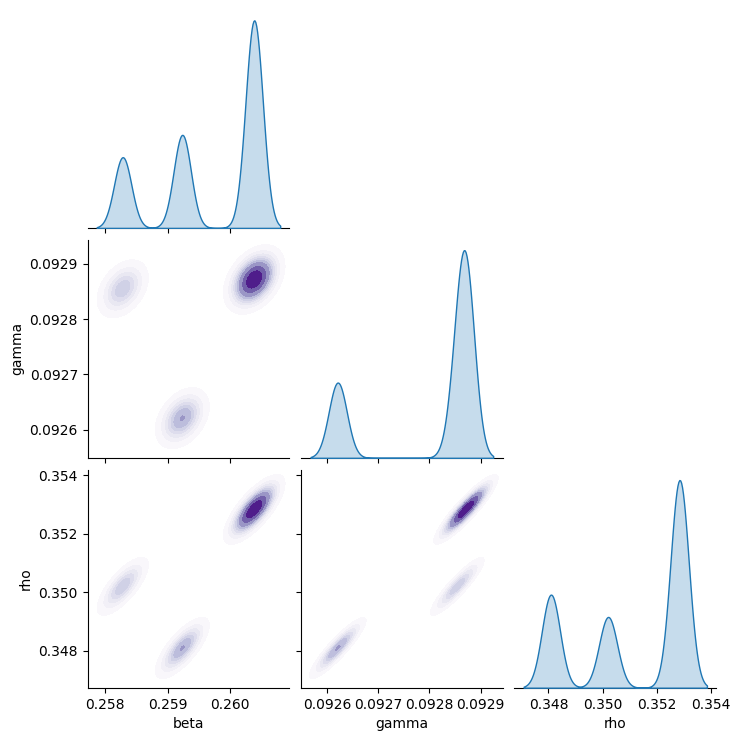

In [34]:
# ---------------------------------------------------------
# 4. Posterior Analysis and Visualization
# ---------------------------------------------------------
df_posterior = pd.DataFrame(final_chain, columns=['beta', 'gamma', 'rho'])

print("\nGenerating Pairwise Plots from Final Phase...")
g = sns.pairplot(df_posterior, kind='kde', corner=True, 
                plot_kws={'fill': True, 'cmap': 'Purples'}) 

if not os.path.exists('plots'):
    os.makedirs('plots')
    
pairplot_path = 'plots/posterior_pairplot_mcmc_1.pdf'
# g.savefig(pairplot_path, format='pdf', bbox_inches='tight')
print(f"Saved MCMC pairplot to: {pairplot_path}")

plt.show()